# 第11回　ワークブック

Python III：pandasで企業データを結合・集計・作図する

2026年11月12日（木）2限　金融論

## 使い方

上から順に、1つずつ実行していくnotebookです。

- 実行する　code cellを選び、Shift+Enterで実行します。押す前に、何が出るか予想します。
- やってみる　すぐ下の `# ここに書きます` のcellに自分で書いて実行します。

errorを確かめるcellは、確かめたら行頭に `#` を付けておきます。6節で全部を実行し直すとき、errorで止まらなくなります。

詰まったら、cellの内容とエラーの表示をCodexに見せて聞けます。「やってみる」の答え合わせも頼めます。

`data/` の表はすべて架空のデータです。列名はJ-Quants APIと同じにしてあります。

- `prices.csv`：第7回と同じ3社の日次株価
- `master.csv`：銘柄コード、会社名、33業種、市場区分
- `fins.csv`：決算短信サマリー（金額は円、株数は株）
- `daily_2025-06-30.csv`：評価日2025年6月30日の全銘柄の株価

5節では、2〜4節の処理をこのnotebookの中で2つの関数にまとめ、同じ結果になることを確かめます。

## 準備

1. `workbook/` folderを、自分の作業場所にコピーします。
2. VS Codeでfolderごと開きます（File → Open Folder）。
3. このnotebookを開き、右上の Select Kernel から `finance-env` を選びます。
4. 下のcellを実行します。表示されたpathに `finance-env` が含まれていれば準備完了です。

In [1]:
import sys
print(sys.executable)

[検証に使用したPython]


# 1. 読み込みと条件抽出

## 1-1　型と欠損を確かめる

実行する

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("data/prices.csv", dtype={"Code": str}, parse_dates=["Date"])
print(prices.shape)
print(prices.dtypes)
prices.isna().sum()

(1545, 14)
Date         datetime64[ns]
Code                 object
O                   float64
H                   float64
L                   float64
C                   float64
Vo                  float64
Va                  float64
AdjFactor           float64
AdjO                float64
AdjH                float64
AdjL                float64
AdjC                float64
AdjVo               float64
dtype: object


Date         0
Code         0
O            1
H            1
L            1
C            1
Vo           0
Va           0
AdjFactor    0
AdjO         1
AdjH         1
AdjL         1
AdjC         1
AdjVo        0
dtype: int64

1,545行、14列です。`Code` は文字列（`object`）、`Date` は日付型（`datetime64`）で読めています。価格の列に欠損が1つずつあります。売買が成立しなかった日です。

やってみる

`dtype` と `parse_dates` を付けずに読み、`Code` の先頭2行と型を表示します。`Code` は整数の `1110` になり、先頭の0が消えます。

In [3]:
# ここに書きます

## 1-2　ifと、列に対する条件

実行する

In [4]:
close = 3958
if close > 3000:
    print("3,000円より高い")

high = prices["C"] > 3000
print(high.head(3))
print("3,000円より高い行の数:", high.sum())
prices[high].head(3)

3,000円より高い
0    False
1    False
2    False
Name: C, dtype: bool
3,000円より高い行の数: 585


,Date,Code,O,H,L,C,Vo,Va,AdjFactor,AdjO,AdjH,AdjL,AdjC,AdjVo
283,2025-02-10,01110,2992.0,3062.0,2990.0,3060.0,33812900.0,1.027010e+11,1.0,2992.0,3062.0,2990.0,3060.0,33812900.0
284,2025-02-11,01110,3056.0,3058.0,3032.0,3034.0,37681500.0,1.146020e+11,1.0,3056.0,3058.0,3032.0,3034.0,37681500.0
289,2025-02-18,01110,2979.0,3025.0,2971.0,3017.0,24741400.0,7.433141e+10,1.0,2979.0,3025.0,2971.0,3017.0,24741400.0


`if` は1つの値について `True` か `False` を判定します。`prices["C"] > 3000` は、1,545行それぞれについて判定した `True`・`False` の列になります。その列を `prices[ ]` に入れると、`True` の行だけが残ります。`True` を1、`False` を0として足すと、条件に合う行の数（585）になります。

やってみる

1. `if prices["C"] > 3000:` と書いて `print("高い")` を実行します。`ValueError: The truth value of a Series is ambiguous` になります。列には値が1,545個あり、どれで判定するか決まらないからです。確かめたら行頭に `#` を付けます。
2. 条件を `&` でつなぎ、銘柄02220の2025年3月27日から4月3日までの `Date`、`C`、`AdjFactor`、`AdjC` を表示します。条件はそれぞれ `( )` で囲みます。4月1日に `AdjFactor` が0.5になり、`C` が約半分になります。

In [5]:
# ここに書きます

## 1-3　Data Wranglerで表を眺める

VS CodeにData Wrangler（Microsoft）の拡張機能を入れると、DataFrameを表の画面で開き、列ごとの型・欠損の数・値の分布を見られます。DataFrameを表示したcellの出力や、notebook上部の Variables から開けます。開き方の細部は、Codexに聞くと画面に合わせて教えてもらえます。

Data Wranglerの画面で列を消したり型を変えたりすると、その操作は画面の中だけで起きます。notebookを上から実行し直しても、その変更は再現されません。型の変換や行の削除は、notebookのcodeに書いて残します。 Data Wranglerは、読み込んだ表を観察して、codeで直すべき点を見つけるために使います。

やってみる

`prices` をData Wranglerで開き、`C` の欠損が1行であることと、その行の `Code` と `Date` を確かめます。下のcellで、同じ行をcodeで表示します。03330の2024年8月5日です。

In [6]:
# ここに書きます

# 2. 結合

## 2-1　株価と企業情報を結ぶ

2024年度の教材では、3社の株価の短い表に、会社名などの表を `left_join` で結びました。pandasでは `merge` を使います。

実行する

In [7]:
master = pd.read_csv("data/master.csv", dtype={"Code": str})
short = prices[prices["Date"].between("2024-08-01", "2024-08-05")][["Date", "Code", "C"]]

merged = short.merge(master, on="Code", how="left")
print("結合前:", len(short), "行　結合後:", len(merged), "行")
merged

結合前: 9 行　結合後: 12 行


,Date,Code,C,CoName,S33Nm,MktNm
0,2024-08-01,01110,2454.0,オートA,輸送用機器,プライム
1,2024-08-02,01110,2492.0,オートA,輸送用機器,プライム
2,2024-08-05,01110,2467.0,オートA,輸送用機器,プライム
3,2024-08-01,02220,2364.0,オートB,輸送用機器,プライム
4,2024-08-02,02220,2322.0,オートB,輸送用機器,プライム
5,2024-08-05,02220,2391.0,オートB,輸送用機器,プライム
6,2024-08-01,03330,3872.0,リテールC,小売業,プライム
7,2024-08-01,03330,3872.0,リテールC,小売業,プライム
8,2024-08-02,03330,3914.0,リテールC,小売業,プライム
9,2024-08-02,03330,3914.0,リテールC,小売業,プライム


結合前は9行（3社×3日）でしたが、結合後は12行です。03330の行が2倍に増えています。

実行する

In [8]:
print("master の行数:", len(master), "　銘柄コードの種類:", master["Code"].nunique())
master[master["Code"].duplicated(keep=False)]

master の行数: 67 　銘柄コードの種類: 66


,Code,CoName,S33Nm,MktNm
23,03330,リテールC,小売業,プライム
66,03330,リテールC,小売業,プライム


`master.csv` には03330の行が2回入っています。2つのfileをつないだときなどに起きます。キーが重複した表と結合すると、相手の行が重複の数だけ複製されます。

## 2-2　validateで重複を止める

実行する

In [9]:
master_u = master.drop_duplicates()
print("重複を除いた master:", len(master_u), "行")

merged = short.merge(master_u, on="Code", how="left", validate="many_to_one")
print("結合後:", len(merged), "行")

重複を除いた master: 66 行
結合後: 9 行


`validate="many_to_one"` は、「左の表は同じコードが何行あってもよいが、右の表ではコードが一意」という条件です。条件が破れていると、結合せずにerrorで止まります。

やってみる

重複を除く前の `master` と、`validate="many_to_one"` で結合します。`MergeError: Merge keys are not unique in right dataset` になります。確かめたら行頭に `#` を付けます。

In [10]:
# ここに書きます

## 2-3　通期決算を選び、訂正開示をそろえる

評価日を2025年6月30日、使う決算を2025年3月期の通期とします。

実行する

In [11]:
fins = pd.read_csv("data/fins.csv", dtype={"Code": str}, parse_dates=["DiscDate", "CurPerEn"])
print("fins:", len(fins), "行")

fy = fins[(fins["CurPerType"] == "FY")
          & fins["DocType"].str.startswith("FYFinancialStatements")
          & (fins["CurPerEn"] == "2025-03-31")
          & (fins["DiscDate"] <= "2025-06-30")]
print("条件に合う行:", len(fy), "　銘柄:", fy["Code"].nunique())
fy["Code"].value_counts().head(3)

fins: 147 行
条件に合う行: 66 　銘柄: 64


Code
01070    2
05550    2
01340    1
Name: count, dtype: int64

147行から、2025年3月期の通期決算で評価日までに開示された行を選ぶと66行、銘柄は64です。05550と01070が2行あります。

実行する

In [12]:
print(fy.loc[fy["Code"] == "05550", ["DiscDate", "Code", "NP", "ShEq", "BPS"]])

fy = fy.sort_values(["Code", "DiscDate"]).drop_duplicates("Code", keep="last")
print("銘柄ごとに最後の開示だけ残した行:", len(fy))

      DiscDate   Code            NP          ShEq      BPS
126 2025-05-14  05550  9.000000e+09  6.000000e+10  1212.12
142 2025-05-28  05550  7.200000e+09  5.820000e+10  1175.76
銘柄ごとに最後の開示だけ残した行: 64


05550は5月14日に開示した後、5月28日に数値を直した開示を出しています（訂正開示）。開示日の順に並べ、銘柄ごとに最後の行を残しました。

やってみる

1. `fins` から、`CurPerType` が `"FY"` の行を `DocType` の条件なしで選び、`DocType` の値ごとの行数を数えます。`EarnForecastRevision`（業績予想の修正）が5行入ります。この行は通期の数値を持っていません。
2. 上の `fy` を作る条件から `DiscDate` の条件を外すと、何行になるか数えます。68行になります。08880の決算は7月10日、08950の訂正開示は7月15日で、どちらも評価日より後です。評価日の投資家はまだ知りません。

In [13]:
# ここに書きます

## 2-4　3つの表を結合し、行数を記録する

実行する

In [14]:
daily = pd.read_csv("data/daily_2025-06-30.csv", dtype={"Code": str}, parse_dates=["Date"])

counts = []
counts.append({"step": "master（重複を除く）", "rows": len(master_u)})
counts.append({"step": "通期決算（銘柄ごとに1行）", "rows": len(fy)})

panel = master_u.merge(fy, on="Code", how="left", validate="one_to_one")
counts.append({"step": "master と決算（left）", "rows": len(panel)})

panel = panel.merge(daily[["Code", "C"]], on="Code", how="left", validate="one_to_one")
counts.append({"step": "株価を結合（left）", "rows": len(panel)})

pd.DataFrame(counts)

,step,rows
0,master（重複を除く）,66
1,通期決算（銘柄ごとに1行）,64
2,master と決算（left）,66
3,株価を結合（left）,66


`how="left"` は、左の表（`master_u`）の行をすべて残します。右の表に相手がない行は、右の列が欠損（`NaN`）になります。

やってみる

1. `master_u` と `fy` を `how="inner"` で結合し、行数を数えます。63行です。`how="left"` の66行との差は08880・06790・09140の3社で、2025年3月期の通期決算がないので落ちます。06790と09140は12月決算です。
2. `fy` を左にして `master_u` と `how="left"` で結合し、`CoName` が欠損の行を表示します。07890が出ます。決算はあるのに、`master.csv` にない銘柄です。

In [15]:
# ここに書きます

# 3. 変数作成と集計

## 3-1　列をまとめて計算する

実行する

In [16]:
panel["Shares"] = panel["ShOutFY"] - panel["TrShFY"]
panel["MV"] = panel["C"] * panel["Shares"]
panel["PBR"] = panel["MV"] / panel["ShEq"]
panel["ROE"] = panel["NP"] / panel["ShEq"]
panel["PBR_BPS"] = panel["C"] / panel["BPS"]

panel[["Code", "CoName", "C", "NP", "ShEq", "PBR", "PBR_BPS", "ROE"]]

,Code,CoName,C,NP,ShEq,PBR,PBR_BPS,ROE
0,01050,ネットA,1832.0,1.226300e+10,1.608000e+11,0.943343,0.943343,0.076262
1,01070,電機C,2582.0,3.181000e+09,3.940000e+10,1.015761,1.015760,0.080736
2,01110,オートA,2254.0,8.820000e+10,9.800000e+11,1.104000,1.103998,0.090000
3,01230,電力J,1450.0,6.480000e+10,1.296300e+12,0.500000,0.500000,0.049988
4,01320,建設A,4305.0,7.391000e+09,1.087000e+11,0.439609,0.439609,0.067994
...,...,...,...,...,...,...,...,...
61,09140,化学D,908.0,NaN,NaN,NaN,NaN,NaN
62,09260,商事E,4515.0,1.138200e+10,1.071000e+11,0.585980,0.585980,0.106275
63,09430,建設C,7230.0,1.615760e+11,1.168000e+12,0.826993,0.826994,0.138336
64,09580,化学E,3730.0,2.607000e+09,2.660000e+10,1.682707,1.682704,0.098008


`panel["NP"] / panel["ShEq"]` は、66行それぞれで割り算をします。1行ずつ取り出す `for` を書く必要はありません。時価総額÷自己資本のPBRと、株価÷BPSのPBRは、BPSの丸めの分を除いて一致します。決算や株価がない行は、PBR・ROEも欠損になります。

やってみる

ROEを `for` で1行ずつ計算し、上の `ROE` 列との差の最大値を表示します。0.0です。同じ結果に、何行のcodeが必要だったかを比べます。

In [17]:
# ここに書きます

## 3-2　標本の条件を1つずつ足す

実行する

In [18]:
financial = ["銀行業", "証券、商品先物取引業", "保険業", "その他金融業"]
steps = [
    ("プライム", panel["MktNm"] == "プライム"),
    ("金融業を除く", ~panel["S33Nm"].isin(financial)),
    ("通期決算がある", panel["NP"].notna() & panel["ShEq"].notna()),
    ("自己資本が正", panel["ShEq"] > 0),
]
keep = pd.Series(True, index=panel.index)
for step, condition in steps:
    keep = keep & condition
    counts.append({"step": step, "rows": int(keep.sum())})

pd.DataFrame(counts)

,step,rows
0,master（重複を除く）,66
1,通期決算（銘柄ごとに1行）,64
2,master と決算（left）,66
3,株価を結合（left）,66
4,プライム,56
5,金融業を除く,51
6,通期決算がある,48
7,自己資本が正,47


条件を足すたびに、残った社数を表に記録しました。ここでの `for` は、4つの条件を順に足すために使っています。1行ずつの計算には使っていません。

実行する

In [19]:
panel.loc[panel["ShEq"] <= 0, ["Code", "CoName", "NP", "ShEq", "ROE", "PBR"]]

,Code,CoName,NP,ShEq,ROE,PBR
54,07770,ネットG,-1.500000e+09,-3.000000e+09,0.5,-10.933333


07770は純利益も自己資本も負で、ROEが+50%と計算されます。自己資本が正の条件を付けないと、この会社がいちばん収益性の高い会社に見えます。赤字の04440は、ROEが−6%として標本に残ります。

## 3-3　欠損を0で埋めない

実行する

In [20]:
kept = panel[keep]
print("社数:", len(kept), "　PBRがある社数:", kept["PBR"].notna().sum())
print("PBRの中央値（欠損を除く）:", round(kept["PBR"].median(), 3))
print("PBRの中央値（欠損を0で埋める）:", round(kept["PBR"].fillna(0).median(), 3))
kept.loc[kept["PBR"].isna(), ["Code", "CoName", "C", "PBR"]]

社数: 47 　PBRがある社数: 46
PBRの中央値（欠損を除く）: 1.342
PBRの中央値（欠損を0で埋める）: 1.198


,Code,CoName,C,PBR
33,04670,電力P,NaN,NaN


04670は評価日に売買が成立せず、株価が欠損です。欠損を0で埋めると、PBRが0倍の会社が1社増えたことになり、中央値が下がります。株価がないことと、株価が0円であることは違います。

実行する

In [21]:
sample = kept[kept["PBR"].notna()].copy()
counts.append({"step": "評価日の株価がある", "rows": len(sample)})
pd.DataFrame(counts)

,step,rows
0,master（重複を除く）,66
1,通期決算（銘柄ごとに1行）,64
2,master と決算（left）,66
3,株価を結合（left）,66
4,プライム,56
5,金融業を除く,51
6,通期決算がある,48
7,自己資本が正,47
8,評価日の株価がある,46


## 3-4　業種別に集計する

実行する

In [22]:
by_industry = (sample.groupby("S33Nm")
               .agg(n=("Code", "count"),
                    PBR_mean=("PBR", "mean"), PBR_median=("PBR", "median"),
                    ROE_mean=("ROE", "mean"), ROE_median=("ROE", "median"))
               .reset_index())
by_industry.round(3)

,S33Nm,n,PBR_mean,PBR_median,ROE_mean,ROE_median
0,サービス業,4,2.236,2.187,0.166,0.157
1,不動産業,2,2.243,2.243,0.144,0.144
2,化学,3,1.717,1.775,0.075,0.094
3,卸売業,5,1.366,0.846,0.093,0.106
4,小売業,5,1.815,1.801,0.115,0.100
5,建設業,3,0.822,0.827,0.111,0.126
6,情報・通信業,8,5.402,2.355,0.141,0.134
7,機械,3,1.057,0.773,0.062,0.074
8,輸送用機器,3,0.803,0.804,0.030,0.060
9,電気・ガス業,1,0.500,0.500,0.050,0.050


情報・通信業はPBRの平均が5.402倍、中央値が2.355倍で、大きく離れています。8社のうち09990のPBRが24.5倍だからです。電気・ガス業は1社しかなく、中央値はその1社の値です。

やってみる

赤字の会社（`NP` が負）を除いた標本で、業種別の社数とROEの中央値を出します。輸送用機器は2社になり、ROEの中央値は6%から7.5%に上がります。

In [23]:
# ここに書きます

# 4. 図と数値の確認

## 4-1　分布を見る

実行する

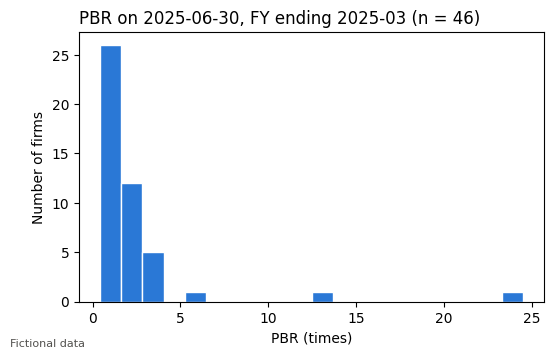

In [24]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(sample["PBR"], bins=20, color="#2a78d6", edgecolor="white")
ax.set_xlabel("PBR (times)")
ax.set_ylabel("Number of firms")
ax.set_title(f"PBR on 2025-06-30, FY ending 2025-03 (n = {len(sample)})", loc="left")
fig.text(0.01, -0.02, "Fictional data", fontsize=8, color="#52514e")
plt.show()

46社のうち44社は0〜6倍に集まり、12倍台と24倍台に1社ずつ離れています。社数は題名に入れました。

## 4-2　散布図

実行する

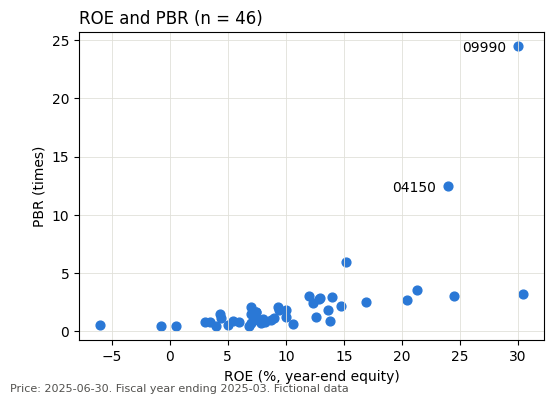

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sample["ROE"] * 100, sample["PBR"], color="#2a78d6", s=40)
for _, row in sample[sample["PBR"] > 10].iterrows():
    ax.annotate(row["Code"], (row["ROE"] * 100, row["PBR"]), xytext=(-40, -4), textcoords="offset points")
ax.set_xlabel("ROE (%, year-end equity)")
ax.set_ylabel("PBR (times)")
ax.set_title(f"ROE and PBR (n = {len(sample)})", loc="left")
ax.grid(color="#e1e0d9", linewidth=0.6)
fig.text(0.01, -0.02, "Price: 2025-06-30. Fiscal year ending 2025-03. Fictional data", fontsize=8, color="#52514e")
plt.show()

09990と04150が上に離れていて、残りの44社の点が下に詰まっています。

## 4-3　外れ値を隠すことと、除くことは違う

実行する

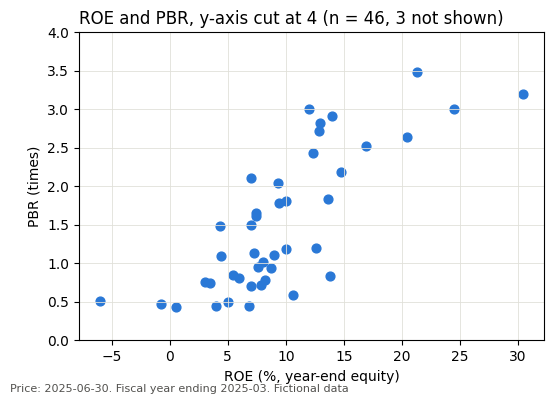

PBRの中央値（46社）: 1.342


In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sample["ROE"] * 100, sample["PBR"], color="#2a78d6", s=40)
ax.set_ylim(0, 4)
hidden = (sample["PBR"] > 4).sum()
ax.set_xlabel("ROE (%, year-end equity)")
ax.set_ylabel("PBR (times)")
ax.set_title(f"ROE and PBR, y-axis cut at 4 (n = {len(sample)}, {hidden} not shown)", loc="left")
ax.grid(color="#e1e0d9", linewidth=0.6)
fig.text(0.01, -0.02, "Price: 2025-06-30. Fiscal year ending 2025-03. Fictional data", fontsize=8, color="#52514e")
plt.show()

print(f"PBRの中央値（{len(sample)}社）:", round(sample["PBR"].median(), 3))

軸の範囲を0〜4に絞ると、09990・04150・06020の3社は図に描かれなくなります。標本は46社のままなので、中央値も約1.342倍のままです。図の題名に、描いていない社数を書きました。

やってみる

`PBR` が10倍以上の会社を標本から除き、社数と、PBRの中央値・平均を表示します。09990と04150の2社が外れて44社、中央値約1.188倍、平均は約1.608倍です。46社のときの平均は約2.342倍でした。除いた場合は、その条件と社数を標本の表に書き足します。

In [27]:
# ここに書きます

## 4-4　図の1点を元の表まで辿る

実行する

In [28]:
code = sample.loc[sample["PBR"].idxmax(), "Code"]
print("PBRが最大の銘柄:", code)
print(master_u[master_u["Code"] == code])
print(fins.loc[fins["Code"] == code, ["DiscDate", "DocType", "CurPerEn", "NP", "ShEq", "BPS", "ShOutFY", "TrShFY"]])
print(daily.loc[daily["Code"] == code, ["Date", "C"]])

PBRが最大の銘柄: 09990
     Code CoName   S33Nm MktNm
65  09990   ネットI  情報・通信業  プライム
     DiscDate                                  DocType   CurPerEn  \
22 2024-05-09  FYFinancialStatements_Consolidated_IFRS 2024-03-31   
69 2025-02-07  3QFinancialStatements_Consolidated_IFRS 2024-12-31   
96 2025-05-09  FYFinancialStatements_Consolidated_IFRS 2025-03-31   

              NP          ShEq    BPS     ShOutFY  TrShFY  
22  4.320000e+09  1.520000e+10  380.0  40000000.0     0.0  
69  3.360000e+09  1.600000e+10  400.0  40000000.0     0.0  
96  4.800000e+09  1.600000e+10  400.0  40000000.0     0.0  
         Date       C
66 2025-06-30  9800.0


09990の2025年3月期の行は、純利益48億円、自己資本160億円、株数4,000万株（自己株式0）です。評価日の終値は9,800円です。

やってみる

上の表示の数字だけを使って、時価総額、PBR、ROEを手で計算するcodeを書きます。時価総額は3,920億円、PBRは24.5倍、ROEは30%です。

In [29]:
# ここに書きます

# 5. 処理を関数にまとめて再実行する

## 5-1　処理を関数にまとめる

2〜4節で1つずつ確かめた処理を、2つの関数にまとめます。

このcellの関数は長いので、行を選んでterminalに送ると途中で崩れます。notebookでは、このcellをそのまま実行すれば定義されます。`build_sample` は3つの表を読んで結合し、条件を1つずつ足して、最後に残った標本と段階ごとの社数の表を返します。`industry_table` は業種別の社数と平均・中央値です。中身は、上で実行したcodeを同じ順に並べたものです。

実行する

In [30]:
def build_sample(data_dir, eval_date, fy_end, how="left"):
    """3つの表を読んで結合し、条件を1つずつ足して、最後に残った標本と段階ごとの社数の表を返す。"""
    counts = []

    def count(step, frame):
        counts.append({"step": step, "rows": len(frame), "companies": frame["Code"].nunique()})

    master = pd.read_csv(f"{data_dir}/master.csv", dtype={"Code": str}).drop_duplicates()
    fins = pd.read_csv(f"{data_dir}/fins.csv", dtype={"Code": str}, parse_dates=["DiscDate", "CurPerEn"])
    daily = pd.read_csv(f"{data_dir}/daily_{eval_date}.csv", dtype={"Code": str}, parse_dates=["Date"])
    count("銘柄の表（重複を除く）", master)

    fy = fins[(fins["CurPerType"] == "FY")
              & fins["DocType"].str.startswith("FYFinancialStatements")
              & (fins["CurPerEn"] == fy_end)
              & (fins["DiscDate"] <= eval_date)]
    fy = fy.sort_values(["Code", "DiscDate"]).drop_duplicates("Code", keep="last")
    count("通期決算（銘柄ごとに1行）", fy)

    panel = master.merge(fy, on="Code", how=how, validate="one_to_one")
    count(f"銘柄と決算の結合（{how}）", panel)
    panel = panel.merge(daily[["Code", "C"]], on="Code", how="left", validate="one_to_one")
    count("評価日の株価を結合", panel)

    panel["Shares"] = panel["ShOutFY"] - panel["TrShFY"]
    panel["MV"] = panel["C"] * panel["Shares"]
    panel["PBR"] = panel["MV"] / panel["ShEq"]
    panel["ROE"] = panel["NP"] / panel["ShEq"]

    financial = ["銀行業", "証券、商品先物取引業", "保険業", "その他金融業"]
    steps = [
        ("プライム", panel["MktNm"] == "プライム"),
        ("金融業を除く", ~panel["S33Nm"].isin(financial)),
        ("通期決算がある", panel["NP"].notna() & panel["ShEq"].notna()),
        ("自己資本が正", panel["ShEq"] > 0),
        ("評価日の株価がある", panel["C"].notna()),
    ]
    keep = pd.Series(True, index=panel.index)
    for step, condition in steps:
        keep = keep & condition
        count(step, panel[keep])
    return panel[keep].copy(), pd.DataFrame(counts)


def industry_table(sample):
    """業種ごとの社数と、PBR・ROEの平均・中央値。"""
    return (sample.groupby("S33Nm")
            .agg(n=("Code", "count"),
                 PBR_mean=("PBR", "mean"), PBR_median=("PBR", "median"),
                 ROE_mean=("ROE", "mean"), ROE_median=("ROE", "median"))
            .reset_index())


sample_fn, counts_fn = build_sample("data", eval_date="2025-06-30", fy_end="2025-03-31")
print(counts_fn)
industry_table(sample_fn).round(3)

             step  rows  companies
0     銘柄の表（重複を除く）    66         66
1   通期決算（銘柄ごとに1行）    64         64
2  銘柄と決算の結合（left）    66         66
3       評価日の株価を結合    66         66
4            プライム    56         56
5          金融業を除く    51         51
6         通期決算がある    48         48
7          自己資本が正    47         47
8       評価日の株価がある    46         46


,S33Nm,n,PBR_mean,PBR_median,ROE_mean,ROE_median
0,サービス業,4,2.236,2.187,0.166,0.157
1,不動産業,2,2.243,2.243,0.144,0.144
2,化学,3,1.717,1.775,0.075,0.094
3,卸売業,5,1.366,0.846,0.093,0.106
4,小売業,5,1.815,1.801,0.115,0.100
5,建設業,3,0.822,0.827,0.111,0.126
6,情報・通信業,8,5.402,2.355,0.141,0.134
7,機械,3,1.057,0.773,0.062,0.074
8,輸送用機器,3,0.803,0.804,0.030,0.060
9,電気・ガス業,1,0.500,0.500,0.050,0.050


社数の表と業種別の表は、2〜4節で1つずつ作ったものと同じです。処理を関数にしておくと、評価日や決算期を変えて同じ手順を繰り返せます。関数は `.py` にも同じまま書けます。`workbook.py` の5節は、このcellと同じ2つの関数です。READMEには、入力のfile、実行する順番、出力のfileを書いておきます。

やってみる

1. `how="inner"` を渡して `build_sample` を実行し、社数の表を比べます。結合の段階は63社になりますが、最後の標本は46社で同じです。
2. `eval_date` を `"2025-07-31"` に変えて実行します。その日の株価の表 `daily_2025-07-31.csv` がないので、`FileNotFoundError` になります。評価日を変えるには、その日の株価も用意する必要があります。確かめたら行頭に `#` を付けます。

In [31]:
# ここに書きます

## 5-2　変更の差分を読む

Gitで管理しているfolderでは、fileを書き換えると、前の版との差分を表示できます。`workbook.py` の `build_sample` の結合方法を `left` から `inner` に書き換えて保存した差分は、次のように表示されます。

```diff
@@ -214,5 +214,5 @@ def build_sample(data_dir, eval_date, fy_end, how="left"):
     fy = fy.sort_values(["Code", "DiscDate"]).drop_duplicates("Code", keep="last")
     count("通期決算（銘柄ごとに1行）", fy)

-    panel = master.merge(fy, on="Code", how=how, validate="one_to_one")
+    panel = master.merge(fy, on="Code", how="inner", validate="one_to_one")
     count(f"銘柄と決算の結合（{how}）", panel)
```

`-` で始まる行が消えた行、`+` で始まる行が加わった行です。`@@` の行は、変更が何行目あたりかを示します。VS CodeのSource Controlの画面でも、同じ差分が左右に並べて表示されます。差分を読むと、引数の `how` が使われなくなり、表の見出しと実際の結合方法が食い違うことに気づけます。Gitの登録やcommitの操作はこの授業では扱いません。

# 6. 最初から実行し直す

1. notebook上部の Restart を押します。kernelの変数がすべて消えます。
2. Run All を押します。上のcellから順に、全部が実行されます。
3. errorで止まったら、そのcellでerrorを確かめた行に `#` が付いているかを見ます。